In [1]:
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
import pickle
from spectral.io import envi

from scipy.signal import medfilt, savgol_filter
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import UnivariateSpline

# %matplotlib widget

In [2]:
home = '/store/carroll/col/data/2018/'

out_figs = '/store/carroll/col/figs/'

fp_rcc_mean = os.path.join(home, 'test_roi', 'rcc_white_tarp_mean_20250807.txt')
fp_rccs = os.path.join(home, 'test_roi', 'rccs_white_tarp_20250807.pkl')

rcc_mean = np.loadtxt(fp_rcc_mean)
with open(fp_rccs, 'rb') as f:
    rccs = pickle.load(f)
    
fp = glob(os.path.join(home, 'test_flightlines', '*', 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

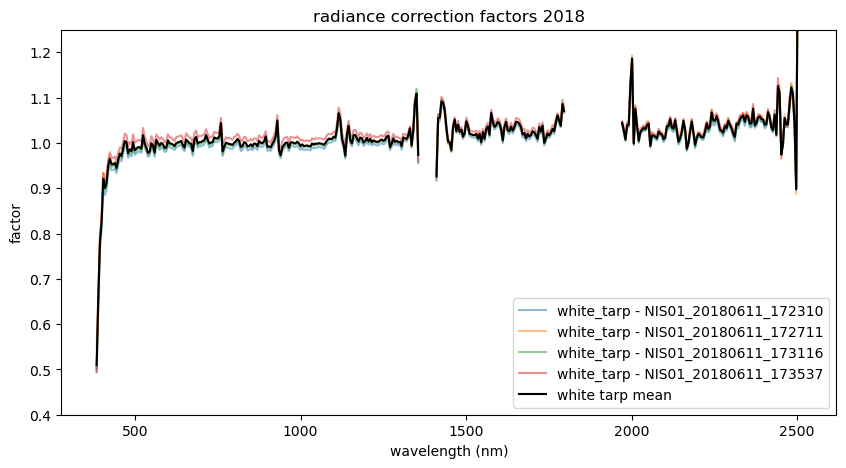

In [3]:
fig = plt.figure(figsize=(10,5))
k = 'white_tarp'
for flight in rccs.keys():
    try:
        rcc_ = rccs[flight][k]
        plt.plot(wl_nan, rcc_, label=f'{k} - {flight}', alpha=0.5)
    except: pass
plt.plot(wl_nan, rcc_mean, color='black', label='white tarp mean')
plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.ylim(0.4, 1.25)
plt.title('radiance correction factors 2018')
plt.legend()

plt.savefig(os.path.join(out_figs, 'raw_rccs_2018.png'), dpi=300)

plt.show()

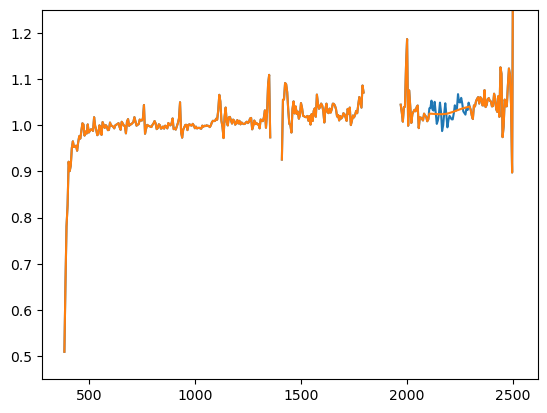

In [6]:
# v1 heavy 1d gaussian filter

# i2065 = closest_wl(2065)
i2104 = closest_wl(2104)
i2300 = closest_wl(2300)
# i2400 = closest_wl(2400)

# replace last 5 values with mean of previous 10
rcc_ = rcc_mean.copy()
rcc_[-5:] = np.mean(rcc_[-15:-5])

# apply filter
smooth_gauss = gaussian_filter1d(rcc_, sigma=9)  
rcc_  = rcc_mean.copy()
rcc_[i2104:i2300] = smooth_gauss[i2104:i2300]

fig = plt.figure()
plt.plot(wl_nan, rcc_mean, label='raw rcc')
plt.plot(wl_nan, rcc_, label='rcc_')
plt.ylim(0.45, 1.25)
plt.show()

# fp_out = os.path.join(home, 'test_roi', 'rcc_white_tarp_mean_20250814_v1.txt')
# np.savetxt(fp_out, rcc_)

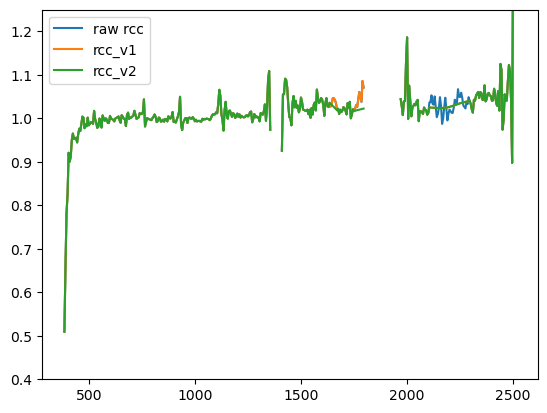

In [7]:
# v2 above + smoothing through other atmospheric windows?

# "windows": [[400.0, 1360.0], [1410, 1800.0], [1970, 2450.0]]

rcc_v1 = np.loadtxt(os.path.join(home, 'test_roi', 'rcc_white_tarp_mean_20250814_v1.txt'))
rcc_v2 = rcc_v1.copy()

# interpolate through the atmospheric windows
x1 = 1360; x2=1410 # just the inversion windows... ? Because I don't see anything funky going on in these regions
y1 = rcc_v1[closest_wl(x1)]; y2 = rcc_v1[closest_wl(x2)]
interp = np.interp(wl[closest_wl(x1):closest_wl(x2)], [x1, x2], [y1, y2])
rcc_v2[closest_wl(x1):closest_wl(x2)] = interp

x1 = 1750; x2=1970 # inversion windows + extra on the low end to avoid the pulling up artifact from 1750-1800
y1 = rcc_v1[closest_wl(x1)]; y2 = rcc_v1[closest_wl(x2)]
interp = np.interp(wl[closest_wl(x1):closest_wl(x2)], [x1, x2], [y1, y2])
rcc_v2[closest_wl(x1):closest_wl(x2)] = interp

# also try to do something about the 1650 peak?
x1 = 1635; x2=1670
y1 = rcc_v1[closest_wl(x1)]; y2 = rcc_v1[closest_wl(x2)]
interp = np.interp(wl[closest_wl(x1):closest_wl(x2)], [x1, x2], [y1, y2])
rcc_v2[closest_wl(x1):closest_wl(x2)] = interp

# wl_ = wl
wl_ = wl_nan

fig = plt.figure()
plt.plot(wl_, rcc_mean, label='raw rcc')
plt.plot(wl_, rcc_v1, label='rcc_v1')
plt.plot(wl_, rcc_v2, label='rcc_v2')
plt.legend()
plt.ylim(0.4, 1.25)
plt.show()

fp_out = os.path.join(home, 'test_roi', 'rcc_white_tarp_mean_20250814_v2.txt')
np.savetxt(fp_out, rcc_v2)